In [1]:
import numpy as np 
import pandas as pd
import glob
from sklearn.preprocessing import RobustScaler

import tensorflow as tf
from tensorflow.keras.layers import Input, LSTM, Concatenate, RepeatVector, TimeDistributed, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import f1_score, classification_report

In [6]:
combined_training_data = pd.concat([pd.read_csv(file) for file in all_training_files], ignore_index=True)

sclr = RobustScaler()
sclr.fit(combined_training_data)

,with_centering,True
,with_scaling,True
,quantile_range,"(25.0, ...)"
,copy,True
,unit_variance,False


In [7]:
def create_windows(file_list, window_size):
    windows = []
    for files in file_list:
        data = pd.read_csv(files)
        
        scaled_data = sclr.transform(data)
        
        for i in range(len(data) - window_size + 1):
            windows.append(scaled_data[i:i+window_size])
        
    return np.array(windows)
        

In [8]:
window_size = 60
X_train = create_windows(all_training_files, window_size)
X_val = create_windows(all_val_files, window_size)
X_test = create_windows(all_testing_files, window_size)

In [9]:
print(X_train.shape)

(187792, 60, 18)


In [10]:
model = Sequential()
model.add(LSTM(64, activation='tanh', input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=False))
model.add(Dropout(0.2)) 
model.add(RepeatVector(X_train.shape[1]))
model.add(LSTM(64, activation='tanh', return_sequences=True))
model.add(Dropout(0.2))
model.add(TimeDistributed(Dense(X_train.shape[2])))

model.compile(optimizer='adam', loss='mse')

c:\Users\Himanshu\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [11]:
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history = model.fit(X_train, X_train, epochs=50, batch_size=128, validation_data=(X_val, X_val), callbacks=[early_stopping],shuffle=True)

Epoch 1/50
1468/1468 ━━━━━━━━━━━━━━━━━━━━ 241s 160ms/step - loss: 0.1336 - val_loss: 0.1812
Epoch 2/50
1468/1468 ━━━━━━━━━━━━━━━━━━━━ 250s 170ms/step - loss: 0.1005 - val_loss: 0.1763
Epoch 3/50
1468/1468 ━━━━━━━━━━━━━━━━━━━━ 252s 172ms/step - loss: 0.0950 - val_loss: 0.1735
Epoch 4/50
1468/1468 ━━━━━━━━━━━━━━━━━━━━ 304s 201ms/step - loss: 0.0907 - val_loss: 0.1674
Epoch 5/50
1468/1468 ━━━━━━━━━━━━━━━━━━━━ 324s 202ms/step - loss: 0.0882 - val_loss: 0.1691
Epoch 6/50
1468/1468 ━━━━━━━━━━━━━━━━━━━━ 260s 177ms/step - loss: 0.0862 - val_loss: 0.1692
Epoch 7/50
1468/1468 ━━━━━━━━━━━━━━━━━━━━ 216s 147ms/step - loss: 0.0848 - val_loss: 0.1692
Epoch 8/50
1468/1468 ━━━━━━━━━━━━━━━━━━━━ 211s 144ms/step - loss: 0.0841 - val_loss: 0.1748
Epoch 9/50
1468/1468 ━━━━━━━━━━━━━━━━━━━━ 227s 154ms/step - loss: 0.0829 - val_loss: 0.1764


In [20]:
# Save entire model
model.save("lstm_autoencoder.keras")

In [12]:
val_label_list = []
for files in all_val_labels:
    val_labels = pd.read_csv(files)
    labels = val_labels["label"].values
    for i in range(len(labels) - window_size + 1):
            val_label_list.append(labels[i + window_size - 1])

val_labels_array = np.array(val_label_list)
print(f"val_labels_array defined. Shape: {val_labels_array.shape}")


val_labels_array defined. Shape: (79098,)


In [13]:
val_predictions = model.predict(X_val)

mse_val = np.mean(np.power(X_val - val_predictions, 2), axis=(1, 2))

print(f"Total Validation Windows (Predictions): {len(mse_val)}")
print(f"Total Validation Labels (Ground Truth): {len(val_labels_array)}")

if len(mse_val) == len(val_labels_array):
    print("Ready for threshold calibration.")
else:
    print("The number of labels does not match the number of windows.")

2472/2472 ━━━━━━━━━━━━━━━━━━━━ 61s 24ms/step
Total Validation Windows (Predictions): 79098
Total Validation Labels (Ground Truth): 79098
Ready for threshold calibration.


In [14]:
best_f1 = 0
best_threshold = 0

for t in np.linspace(np.min(mse_val), np.max(mse_val), 100):
    y_pred_val = (mse_val > t).astype(int)
    
    # Change y_val to val_labels_array here:
    current_f1 = f1_score(val_labels_array, y_pred_val) 
    
    if current_f1 > best_f1:
        best_f1 = current_f1
        best_threshold = t

print(f"Best Threshold: {best_threshold:.4f}")
print(f"Best F1 Score: {best_f1:.4f}")

Best Threshold: 0.0068
Best F1 Score: 0.3888


In [15]:
test_predictions = model.predict(X_test)
mse_test = np.mean(np.power(X_test - test_predictions, 2), axis=(1, 2))

y_pred_test = (mse_test > best_threshold).astype(int)

9779/9779 ━━━━━━━━━━━━━━━━━━━━ 245s 25ms/step


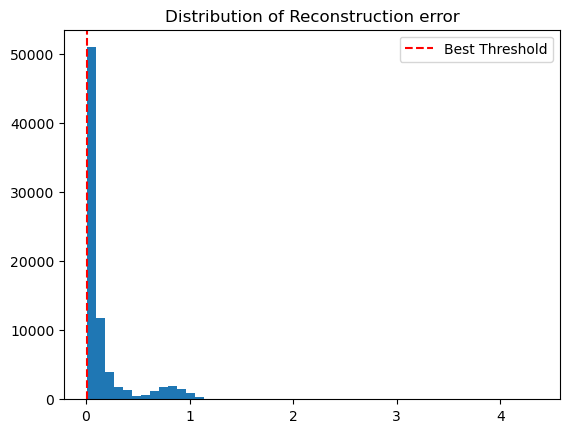

In [16]:
import matplotlib.pyplot as plt

plt.hist(mse_val, bins=50)
plt.axvline(best_threshold, color='r', linestyle='--', label='Best Threshold')
plt.title("Distribution of Reconstruction error")
plt.legend()
plt.show()

In [17]:
# Focus the search between the 50th and 99th percentile
search_range = np.linspace(np.percentile(mse_val, 50), np.percentile(mse_val, 99.9), 200)

best_f1 = 0
best_threshold = 0

for t in search_range:
    y_pred_val = (mse_val > t).astype(int)
    current_f1 = f1_score(val_labels_array, y_pred_val)
    if current_f1 > best_f1:
        best_f1 = current_f1
        best_threshold = t
        
print(f"Refined Best Threshold: {best_threshold:.4f}")
print(f"Refined Best F1 Score: {best_f1:.4f}")

Refined Best Threshold: 0.0411
Refined Best F1 Score: 0.3618


In [22]:
manual_t = 0.6
y_pred_manual = (mse_val > manual_t).astype(int)
print(f"Manual F1 Score at 0.8: {f1_score(val_labels_array, y_pred_manual)}")

Manual F1 Score at 0.8: 0.24947994598737272


In [19]:
print(f"Anomaly count in validation: {np.sum(val_labels_array)}")
print(f"Normal count in validation: {len(val_labels_array) - np.sum(val_labels_array)}")

Anomaly count in validation: 19086
Normal count in validation: 60012
